In [87]:
!pip install gensim
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gdown

In [163]:
# для начала загружаем данные
url = 'https://drive.google.com/uc?id=1zLs02TTxbt1Htk1RdIJM5AaBacs6Y39K'
output = 'stackoverflow_questions.csv'
gdown.download(url, output, quiet=False)
df = pd.read_csv(output).sample (800)
texts = df['Question'].values

Downloading...
From: https://drive.google.com/uc?id=1zLs02TTxbt1Htk1RdIJM5AaBacs6Y39K
To: /content/stackoverflow_questions.csv
100%|██████████| 43.6M/43.6M [00:00<00:00, 63.8MB/s]


In [164]:
print(texts[:5])

["I'm working in an intelligence agency. Each and every agent of that agency has to provide their generated number on a certain page before they can access some pages. In our CustomUser model, we have a field that asks the user for their full name. We want the name to appear in the 'name' field of the Access model in real-time. What we want is that when someone types their number in the Access model, their full name in the CustomUser model should appear in the 'name' field of the Access model in real-time.My signals:@receiver(post_save, sender=User)def generate_number(sender, instance, created, **kwargs):    if created:        random_number = ''.join(random.choices(string.digits, k=10)        Account.objects.create(user=instance, secret_number=random_number)My models:class Account(models.Model):    user = models.ForeinKey(settings.AUTH_USER_MODEL, on_delete=models.CASCADE)    secret_number = models.IntegerField()Class Access(models.Model):    user = models.ForeinKey(settings.AUTH_USER_

1.	Реализация k-means
a.	Векторизуйте исходные тексты без предварительной обработки тремя способами

Способ 1. TF-IDF (без предобработки)

Для начала формула:

TfidfVectorizer Формула TF-IDF:

TF (Term Frequency) = (количество вхождений слова в документе) / (общее количество слов в документе)

IDF (Inverse Document Frequency) = log((общее количество документов) / (количество документов, содержащих слово))

TF-IDF = TF * IDF

TF-IDF увеличивает вес слов, которые часто встречаются в конкретном документе, но редко встречаются в других документах коллекции.

TF-IDF учитывает не только частоту слова в документе, но и его важность в коллекции документов!

In [165]:
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(texts)

Способ 2. CountVectorizer (без предобработки)

In [166]:
# Векторизация без обработки
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_cv = CountVectorizer()
X_cv = vectorizer_cv.fit_transform(texts)

Способ 3. Glove с использованием через Gensim (без предобработки)

скачиваем с сайта данные для Glove

In [167]:
# Загрузка предобученной модели GloVe через Gensim
import gensim.downloader as api
glove_model = api.load("glove-wiki-gigaword-100")

Чтобы получить вектор текста - усреднияем вектора входящих в него слов

In [168]:
#Получение вектора текста — усреднение векторов слов
def text_to_glove(text):
    words = re.findall(r'\b\w+\b', text.lower())
    vectors = []
    for word in words:
        if word in glove_model:
            vectors.append(glove_model[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(glove_model.vector_size)

X_glove = np.array([text_to_glove(text) for text in texts])

b.	Определяем количество кластеров

In [169]:
#Определение количества кластеров
# Метод "локтя" для определения оптимального числа кластеров
import matplotlib.pyplot as plt

def find_optimal_k(X):
    sse = []
    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        sse.append(kmeans.inertia_)
    plt.plot(range(2, 11), sse, marker='o')
    plt.xlabel('Number of clusters k')
    plt.ylabel('SSE')
    plt.show()

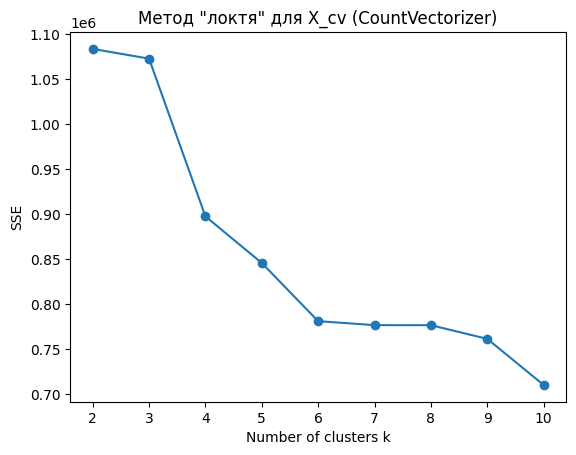

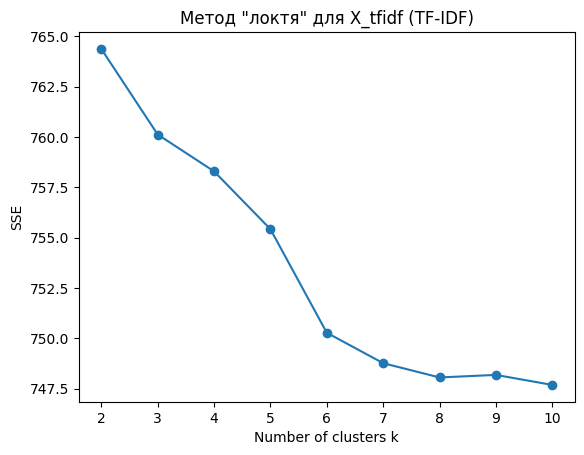

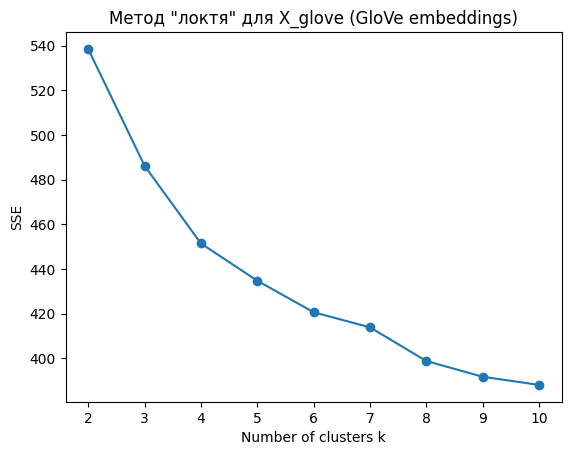

In [170]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def find_optimal_k(X, title=''):
    sse = []
    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        sse.append(kmeans.inertia_)
    plt.plot(range(2, 11), sse, marker='o')
    plt.xlabel('Number of clusters k')
    plt.ylabel('SSE')
    plt.title(f'Метод "локтя" для {title}')
    plt.show()

# Вызовы функции
find_optimal_k(X_cv, title='X_cv (CountVectorizer)')
find_optimal_k(X_tfidf, title='X_tfidf (TF-IDF)')
find_optimal_k(X_glove, title='X_glove (GloVe embeddings)')

Метод локтя помогает определить оптимальное число кластеров по графику, где по оси откладывается число кластеров, а по оси — значение метрики, например, SSE.

c.	Реализуем кластеризацию (x3)

In [171]:
#Кластеризация (x3)
# возьмем k=4
k = 4

# 1) KMeans с CountVectorizer
kmeans_cv = KMeans(n_clusters=k, random_state=42).fit(X_cv)

# 2) KMeans с TfidfVectorizer
kmeans_tfidf = KMeans(n_clusters=k, random_state=42).fit(X_tfidf)

# 3) KMeans с GloVe
kmeans_glove = KMeans(n_clusters=k, random_state=42).fit(X_glove)

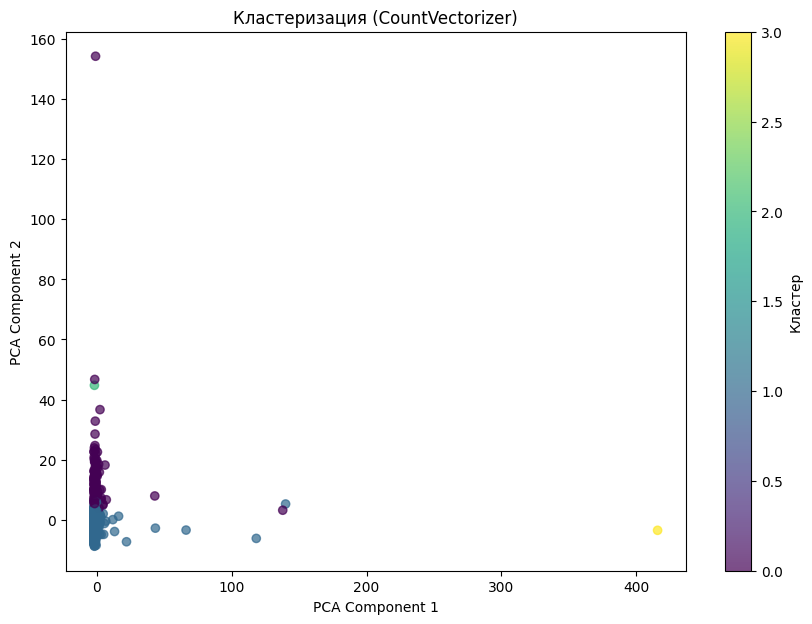

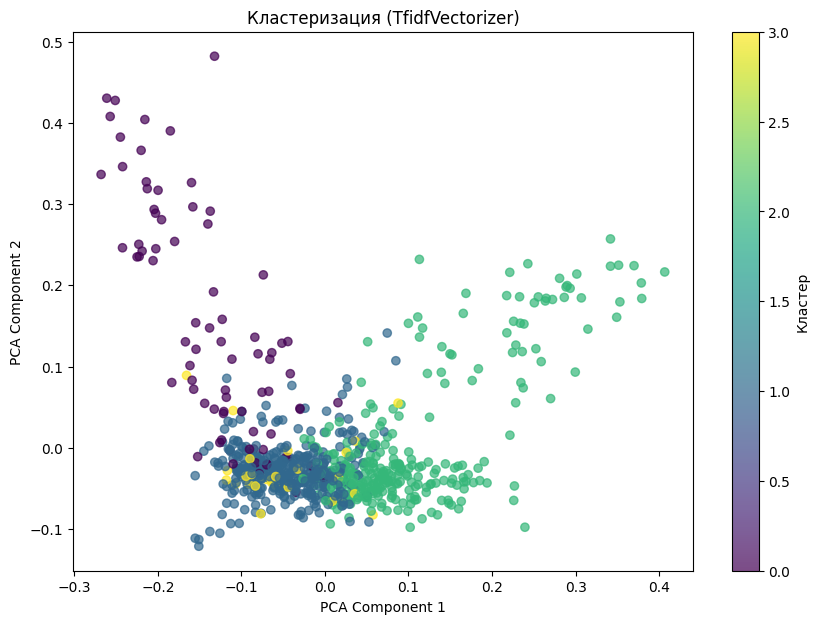

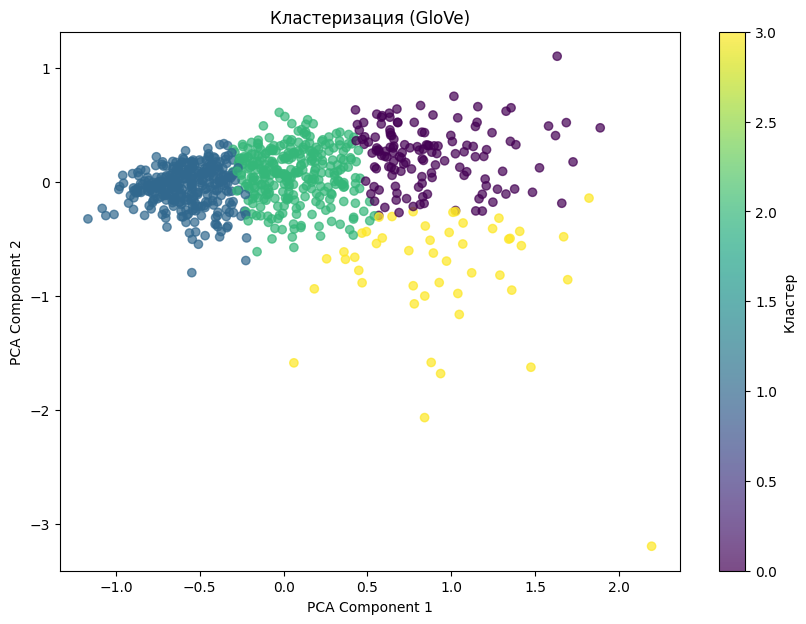

In [172]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Функция для визуализации
def plot_clusters(X, labels, title):
    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)
    plt.figure(figsize=(10, 7))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.colorbar(label='Кластер')
    plt.show()

# Визуализируем CountVectorizer
plot_clusters(X_cv.toarray(), kmeans_cv.labels_, 'Кластеризация (CountVectorizer)')

# Визуализируем TfidfVectorizer
plot_clusters(X_tfidf.toarray(), kmeans_tfidf.labels_, 'Кластеризация (TfidfVectorizer)')

# Визуализируем GloVe
plot_clusters(X_glove, kmeans_glove.labels_, 'Кластеризация (GloVe)')

d.	Находим по 1 ближайшему тексту к центроидам полученных кластеров.

 Можно ли с их помощью описать полученный кластер? - да! с помощью ближайших к центроиду текстов действлиельно можно эффективно описать полученный кластер:
 для этого и используются представительные тексты:
ближайшие к центроиду тексты служат как "примерные"  для этого кластера.


In [173]:
from sklearn.metrics.pairwise import euclidean_distances

def find_closest_texts(kmeans, X, texts, vectorizer_type):
    centers = kmeans.cluster_centers_
    closest_texts = []

    print(f"\nБлижайшие тексты к центроидам ({vectorizer_type})")

    for i, centroid in enumerate(centers):
        distances = euclidean_distances(X, centroid.reshape(1, -1)).flatten()
        idx = np.argmin(distances)
        closest_texts.append(texts[idx])

        print(f"\nКластер {i+1}:")
        print(f"Текст-представитель: {texts[idx]}")
        print(f"Длина текста: {len(texts[idx].split())} слов")
        print(f"Расстояние до центроида: {distances[idx]:.2f}")

    return closest_texts

# Для CountVectorizer
print("\n" + "="*50)
print("Анализ кластеров (CountVectorizer)")
print("="*50)
closest_cv = find_closest_texts(kmeans_cv, X_cv, texts, "CountVectorizer")

# Для TfidfVectorizer
print("\n" + "="*50)
print("Анализ кластеров (TfidfVectorizer)")
print("="*50)
closest_tfidf = find_closest_texts(kmeans_tfidf, X_tfidf, texts, "TfidfVectorizer")

# Дополнительный анализ
print("\n" + "="*50)
print("Сравнение методов векторизации")
print("="*50)
print(f"Совпадения между методами CV и TF-IDF: {len(set(closest_cv) & set(closest_tfidf))}/{len(closest_cv)}")
print("\nПримеры различий:")
for i, (cv, tfidf) in enumerate(zip(closest_cv, closest_tfidf)):
    if cv != tfidf:
        print(f"\nКластер {i+1}:")
        print(f"CountVectorizer: {cv}")
        print(f"TF-IDF: {tfidf}")


Анализ кластеров (CountVectorizer)

Ближайшие тексты к центроидам (CountVectorizer)

Кластер 1:
Текст-представитель: I'm new to the nidaqmx library, and I wondered if there is a way to read from the default sample clock in the NIDAQ(USB-6346) card. I want to do this to figure out the time it takes to collect a particular number of samples. Any responses/solutions would be much appreciated! This is also the first question I posted on Stackoverflow, so I'm unfamiliar with the formats and such.What I tried:I tried using the time/datetime modules in Python already, but it doesn't seem like a very accurate way to measure the (elapsed) time it takes to collect samples. For example, If I use that to find the time it takes to collect 10 samples at 10Hz, the output would be 1.02 seconds rather than 1 second.I've also tried accessing the default clock through the methods in the nidaqmx documentation and searching in the Stackoverflow/ni community discussion forums, but I still have difficulties

e.	Обрабатываем тексты

In [174]:
#Обработка текстов и повторное выполнение
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

i.	"очищаем" тексты

In [175]:
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [176]:
import nltk
nltk.download('punkt_tab')
def preprocess_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    # Удаление лишних символов
    text = re.sub(r'[^a-z\s]', '', text)
    # Токенизация
    words = nltk.word_tokenize(text)
    # Удаление стоп-слов
    words = [word for word in words if word not in stop_words]
    # Лемматизация
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

processed_texts = [preprocess_text(t) for t in texts]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [177]:
# Пример исходного текста
print("Исходный текст:\n", texts[0])

# Обработанный текст
print("\nОбработанный текст:\n", processed_texts[0])

Исходный текст:
 I'm working in an intelligence agency. Each and every agent of that agency has to provide their generated number on a certain page before they can access some pages. In our CustomUser model, we have a field that asks the user for their full name. We want the name to appear in the 'name' field of the Access model in real-time. What we want is that when someone types their number in the Access model, their full name in the CustomUser model should appear in the 'name' field of the Access model in real-time.My signals:@receiver(post_save, sender=User)def generate_number(sender, instance, created, **kwargs):    if created:        random_number = ''.join(random.choices(string.digits, k=10)        Account.objects.create(user=instance, secret_number=random_number)My models:class Account(models.Model):    user = models.ForeinKey(settings.AUTH_USER_MODEL, on_delete=models.CASCADE)    secret_number = models.IntegerField()Class Access(models.Model):    user = models.ForeinKey(sett

f.	Повторяем пункты a-d:
i.	CountVectorizer
ii.	TfidfVectorizer
iii.	Glove с использованием через Gensim
Чтобы получить вектор текста - усредните вектора входящих в него слов


In [178]:
# CountVectorizer
vectorizer_cv_proc = CountVectorizer()
X_cv_proc = vectorizer_cv_proc.fit_transform(processed_texts)

In [179]:
# TfidfVectorizer
vectorizer_tfidf_proc = TfidfVectorizer()
X_tfidf_proc = vectorizer_tfidf_proc.fit_transform(processed_texts)

In [180]:
# GloVe (усреднение слов)
X_glove_proc = np.array([text_to_glove(text) for text in processed_texts])

In [181]:
# Кластеризация
kmeans_cv_proc = KMeans(n_clusters=k, random_state=42).fit(X_cv_proc)
kmeans_tfidf_proc = KMeans(n_clusters=k, random_state=42).fit(X_tfidf_proc)
kmeans_glove_proc = KMeans(n_clusters=k, random_state=42).fit(X_glove_proc)

In [182]:
def get_closest_texts(kmeans_model, data_vectors, original_texts):
    # Вычисляем расстояния до центроидов
    distances = euclidean_distances(data_vectors, kmeans_model.cluster_centers_)

    # Находим индекс ближайшего центра и расстояние для каждого образца
    nearest_indices = distances.argmin(axis=1)
    nearest_distances = distances.min(axis=1)

    # Для каждого кластера собираем наиболее близкий к центроиду текст
    closest_texts = []
    for cluster_idx in range(kmeans_model.n_clusters):
        # Находим все образцы, принадлежащие текущему кластеру
        cluster_members = [i for i, label in enumerate(kmeans_model.labels_) if label == cluster_idx]
        # Среди них находим тот, что ближе всего к центроиду
        min_distance_idx = cluster_members[nearest_distances[cluster_members].argmin()]
        closest_texts.append(original_texts[min_distance_idx])

    # Возвращаем список текстов, а также расстояния и индексы
    return closest_texts, nearest_distances, nearest_indices

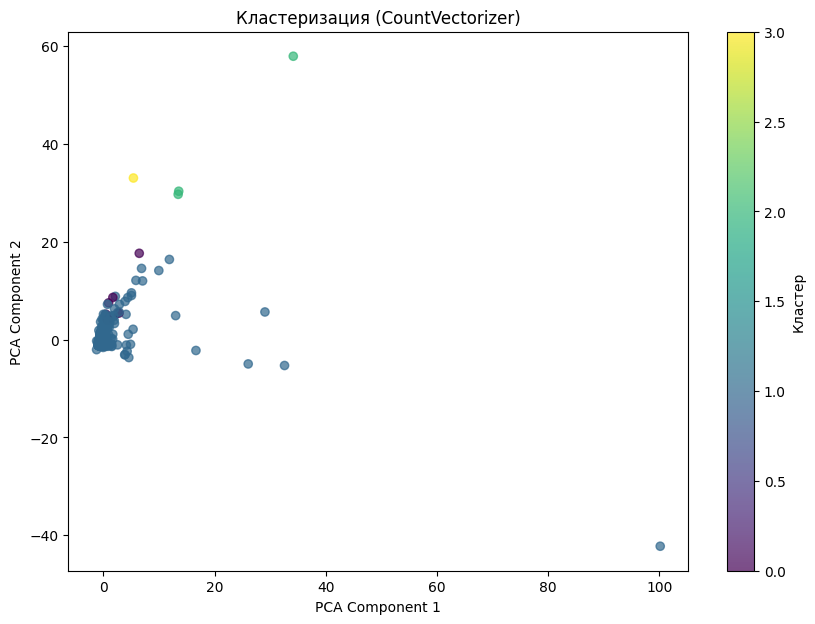

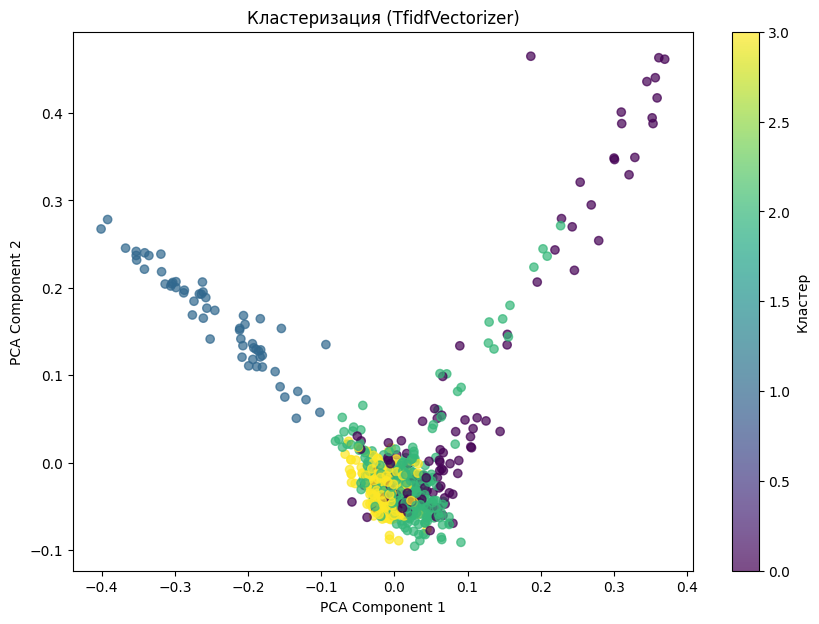

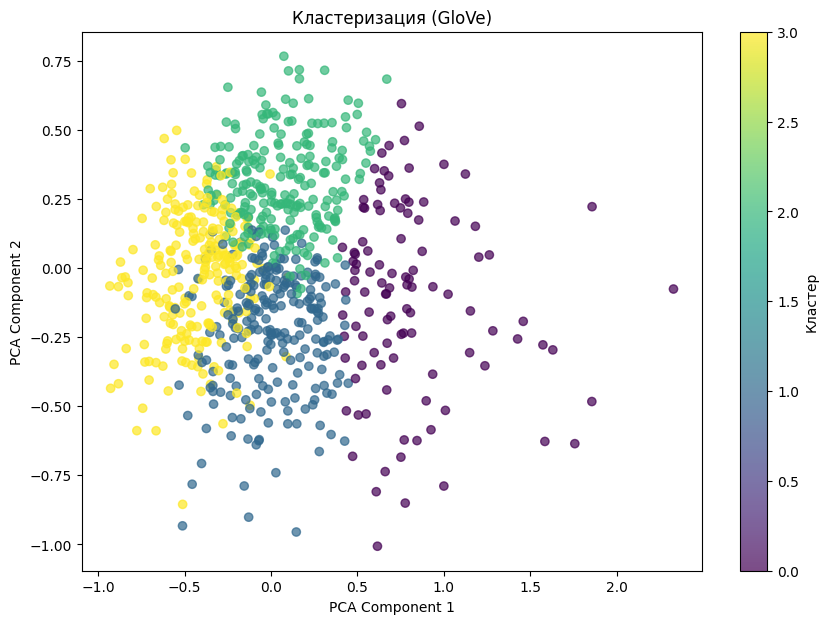

In [183]:
# Функция для визуализации
def plot_clusters(X, labels, title):
    pca = PCA(n_components=2)
    X_reduced = pca.fit_transform(X)
    plt.figure(figsize=(10, 7))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.colorbar(label='Кластер')
    plt.show()

# Визуализация для CountVectorizer
plot_clusters(X_cv_proc.toarray(), kmeans_cv_proc.labels_, 'Кластеризация (CountVectorizer)')

# Визуализация для TfidfVectorizer
plot_clusters(X_tfidf_proc.toarray(), kmeans_tfidf_proc.labels_, 'Кластеризация (TfidfVectorizer)')

# Визуализация для GloVe
plot_clusters(X_glove_proc, kmeans_glove_proc.labels_, 'Кластеризация (GloVe)')


In [135]:
# GloVe после обработки
closest_texts, distances, indices = get_closest_texts(kmeans_glove_proc, X_glove_proc, texts)

for i, (text, dist, idx) in enumerate(zip(closest_texts, distances, indices)):
    print(f"\nКластер {i+1}:")
    print(f"Текст-представитель: {text}")
    print(f"Длина текста: {len(text.split())} слов")
    print(f"Расстояние до центроида: {dist:.2f}")


Кластер 1:
Текст-представитель: The bounty expires in 16 hours. Answers to this question are eligible for a +100 reputation bounty. Marco Luzzara is looking for an answer from a reputable source:The answer should explain why it does not work with AWS integration type and how to make it work. Some insights on what is going on in the background is appreciated. If the problem is on my usage of the Spring Cloud Function library, then I would like an example of how to rewrite it.I am using Localstack with API Gateway and Lambda Integration to test my APIs. You can find the repository here.The scripts I am using to build the emulated AWS environment are in this folder.I am trying to create multiple integration responses for a single API, which is GET /users/{userId}. I have integrated the Lambda function with the API Gateway, the integration type is AWS. The issue is that the default response is always called (200), whereas I would like to return 404 when the user does not exist. It should 

Если мы сравним результаты кластеризации до и после обработки, то мы видим что ДО:
исходные тексты очень длинные, содержат много технической информации, деталей и тд.
ПОСЛЕ: тексты для каждого кластера — самые ближайшие к центроидам. Они содержат те же идеи, что и исходные, но они короче, сжаты или сфокусированы на ключевых аспектах.

In [184]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X_glove_proc)

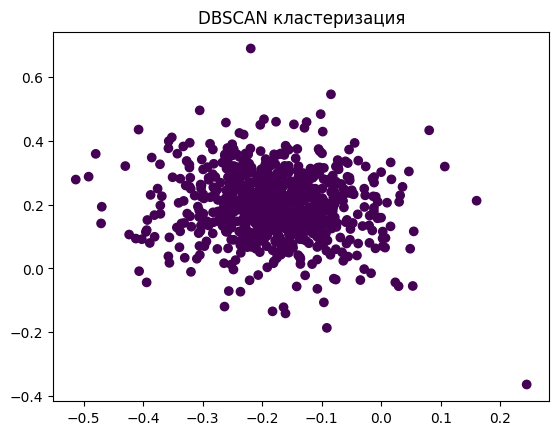

In [185]:
import matplotlib.pyplot as plt

plt.scatter(X_glove_proc[:, 0], X_glove_proc[:, 1], c=labels_dbscan)
plt.title('DBSCAN кластеризация')
plt.show()

(№3) ЗАДАНИЕ СО ЗВЕЗДОЧКОЙ
реализуйте векторизацию через sentence-transformers. Примените какой-то из алгоритмов кластеризации

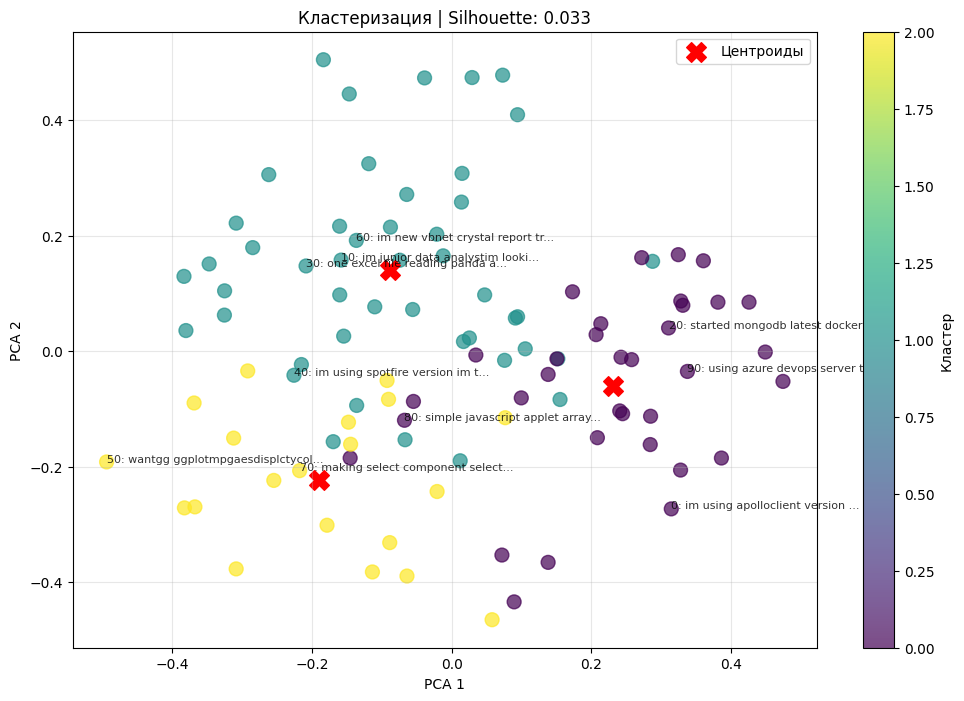

In [188]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
import random
# Поскольку объем у нас большой, введем ограничения - случайные данные
sample_size = 100
indices = random.sample(range(len(processed_texts)), min(sample_size, len(processed_texts)))
texts_sample = [processed_texts[i] for i in indices]

# 1. Векторизация
model = SentenceTransformer('all-MiniLM-L6-v2')
X_sbert = model.encode(texts_sample)

# 2. Кластеризация
k = 3
kmeans = KMeans(n_clusters=k, random_state=42).fit(X_sbert)
labels = kmeans.labels_

# PCA - получаем двумерное изображение
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sbert)

#Визуализация
plt.figure(figsize=(12,8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7, s=100)
plt.colorbar(scatter, label='Кластер')
score = silhouette_score(X_sbert, labels)
plt.title(f'Кластеризация | Silhouette: {score:.3f}')
for i, (x, y) in enumerate(zip(X_pca[:, 0], X_pca[:, 1])):
    if i % 10 == 0:
        plt.annotate(f"{i}: {texts_sample[i][:30]}...", (x, y), fontsize=8, alpha=0.8)

# 6. Центроиды
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Центроиды')
plt.legend()

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True, alpha=0.3)
plt.show()

ЗАДАНИЕ СО ЗВЕЗДОЧКОЙ 2 - Попробуйте применить BERTopic

In [109]:
!pip install bertopic
!pip install --upgrade numpy  # Важно для совместимости
!pip install umap-learn      # Необходимо для BERTopic
from bertopic import BERTopic
import matplotlib.pyplot as plt

  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
  Using cached numpy-2.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.me

In [190]:
# Создаем модель с простыми настройками (чтобы быстрее загружалось!!!)
topic_model = BERTopic(
    language="english",
    nr_topics='auto',
    verbose=False,
    top_n_words=10,
    min_topic_size=20
)

In [191]:
# Обучение модели
topics, probs = topic_model.fit_transform(processed_texts)

In [192]:
# Визуализация топ-10 тем
topic_model.visualize_barchart(top_n_topics=10)

ЗАДАНИЕ СО ЗВЕЗДОЧКОЙ 3

In [143]:
!pip install gensim
!pip install --upgrade numpy gensim  # Обновляем numpy и gensim для совместимости

from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import preprocess_string, STOPWORDS
from gensim.utils import simple_preprocess

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


In [193]:
# предобрабатываем тексты для LDA
processed_docs = [preprocess_string(text) for text in texts]

# создаем словарь и корпуса
dictionary = corpora.Dictionary(processed_docs)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# обучеам LDA модель
lda_model = LdaModel(corpus=corpus,
                    id2word=dictionary,
                    num_topics=k,
                    random_state=42,
                    passes=10)

In [194]:
# отображение тем
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.008*"data" + 0.008*"user" + 0.008*"valu" + 0.006*"item" + 0.006*"file" + 0.005*"class" + 0.005*"self" + 0.005*"code" + 0.005*"return" + 0.005*"new"

Topic: 1 
Words: 0.026*"java" + 0.018*"org" + 0.010*"player" + 0.007*"test" + 0.005*"data" + 0.005*"com" + 0.005*"scala" + 0.005*"model" + 0.004*"execut" + 0.004*"return"

Topic: 2 
Words: 0.008*"app" + 0.008*"error" + 0.007*"const" + 0.007*"file" + 0.007*"data" + 0.006*"code" + 0.005*"work" + 0.005*"return" + 0.005*"try" + 0.005*"list"

